<a href="https://colab.research.google.com/github/udayanjansai/ML_For_Autism_Detection/blob/main/ASD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
#Load Data sets
child = pd.read_csv("/content/drive/MyDrive/datasets/Autism_Child_Data.csv")
adult = pd.read_csv("/content/drive/MyDrive/datasets/Autism_Adult_Data.csv")
adolescent = pd.read_csv("/content/drive/MyDrive/datasets/Autism_Adolescent_Data.csv")
screening = pd.read_csv("/content/drive/MyDrive/datasets/Toddler Autism dataset July 2018.csv")

In [39]:
print("Child:", child.columns.tolist())
print("Adult:", adult.columns.tolist())
print("Adolescent:", adolescent.columns.tolist())
print("Screening:", screening.columns.tolist())


Child: ['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']
Adult: ['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']
Adolescent: ['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']
Screening: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the 

In [40]:
print("Child dataset:", child.shape)
print("Adult dataset:", adult.shape)
print("Adolescent dataset:", adolescent.shape)
print("Screening dataset:", screening.shape)

Child dataset: (292, 22)
Adult dataset: (704, 22)
Adolescent dataset: (104, 22)
Screening dataset: (1054, 19)


In [41]:
screening.rename(columns={
    'A1': 'A1_Score',
    'A2': 'A2_Score',
    'A3': 'A3_Score',
    'A4': 'A4_Score',
    'A5': 'A5_Score',
    'A6': 'A6_Score',
    'A7': 'A7_Score',
    'A8': 'A8_Score',
    'A9': 'A9_Score',
    'A10': 'A10_Score',
    'Sex': 'gender',
    'Ethnicity': 'ethnicity',
    'Jaundice': 'jundice',
    'Family_mem_with_ASD': 'austim',
    'Class/ASD Traits ': 'Class/ASD'
}, inplace=True)


In [42]:
screening["age"] = screening["Age_Mons"] / 12

In [43]:
selected_cols = [
    'A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
    'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score',
    'age','gender','ethnicity','jundice','austim',
    'Class/ASD'
]

In [44]:
child = child[selected_cols]
adult = adult[selected_cols]
adolescent = adolescent[selected_cols]
screening = screening[selected_cols]

In [45]:

print("Child:", child.shape)
print("Adult:", adult.shape)
print("Adolescent:", adolescent.shape)
print("Screening:", screening.shape)

Child: (292, 16)
Adult: (704, 16)
Adolescent: (104, 16)
Screening: (1054, 16)


In [46]:
from sklearn.utils import resample
target_size = 500

child_bal = resample(child, replace=True, n_samples=target_size, random_state=42)
adult_bal = resample(adult, replace=True, n_samples=target_size, random_state=42)
adolescent_bal = resample(adolescent, replace=True, n_samples=target_size, random_state=42)
screening_bal = resample(screening, replace=True, n_samples=target_size, random_state=42)

combined = pd.concat(
    [child_bal, adult_bal, adolescent_bal, screening_bal],
    ignore_index=True
)

In [47]:
df=combined
print("\nShape:")
print(df.shape)


Shape:
(2000, 16)


In [48]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
A1_Score     0
A2_Score     0
A3_Score     0
A4_Score     0
A5_Score     0
A6_Score     0
A7_Score     0
A8_Score     0
A9_Score     0
A10_Score    0
age          0
gender       0
ethnicity    0
jundice      0
austim       0
Class/ASD    0
dtype: int64


In [49]:
print("\nTarget distribution:")
print(df["Class/ASD"].value_counts())


Target distribution:
Class/ASD
NO     811
YES    689
Yes    348
No     152
Name: count, dtype: int64


In [50]:
import pandas as pd


print("Before cleaning:")
print(df["Class/ASD"].value_counts())

df["Class/ASD"] = (
    df["Class/ASD"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nAfter fixing target labels:")
print(df["Class/ASD"].value_counts())

df["ethnicity"] = df["ethnicity"].replace("?", pd.NA)
df["ethnicity"].fillna(df["ethnicity"].mode()[0], inplace=True)

for col in ["gender", "jundice", "austim"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()




Before cleaning:
Class/ASD
NO     811
YES    689
Yes    348
No     152
Name: count, dtype: int64

After fixing target labels:
Class/ASD
YES    1037
NO      963
Name: count, dtype: int64


/tmp/ipython-input-227118249.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ethnicity"].fillna(df["ethnicity"].mode()[0], inplace=True)


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   A1_Score   2000 non-null   int64 
 1   A2_Score   2000 non-null   int64 
 2   A3_Score   2000 non-null   int64 
 3   A4_Score   2000 non-null   int64 
 4   A5_Score   2000 non-null   int64 
 5   A6_Score   2000 non-null   int64 
 6   A7_Score   2000 non-null   int64 
 7   A8_Score   2000 non-null   int64 
 8   A9_Score   2000 non-null   int64 
 9   A10_Score  2000 non-null   int64 
 10  age        2000 non-null   object
 11  gender     2000 non-null   object
 12  ethnicity  2000 non-null   object
 13  jundice    2000 non-null   object
 14  austim     2000 non-null   object
 15  Class/ASD  2000 non-null   object
dtypes: int64(10), object(6)
memory usage: 250.1+ KB


In [52]:

print("\nDataset cleaned and saved.")
print("Final shape:", df.shape)


Dataset cleaned and saved.
Final shape: (2000, 16)


In [53]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
YES,1037
NO,963


In [54]:



count_q = (df["age"] == "?").sum()

print("Number of '?' in age:", count_q)
print("Total rows:", len(df))
print("Percentage:", (count_q / len(df)) * 100)


Number of '?' in age: 10
Total rows: 2000
Percentage: 0.5


In [55]:
df = df[df["age"] != "?"]
df.loc[:, "age"] = pd.to_numeric(df["age"])

print("Rows after removal:", df.shape)


Rows after removal: (1990, 16)


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1990 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   A1_Score   1990 non-null   int64 
 1   A2_Score   1990 non-null   int64 
 2   A3_Score   1990 non-null   int64 
 3   A4_Score   1990 non-null   int64 
 4   A5_Score   1990 non-null   int64 
 5   A6_Score   1990 non-null   int64 
 6   A7_Score   1990 non-null   int64 
 7   A8_Score   1990 non-null   int64 
 8   A9_Score   1990 non-null   int64 
 9   A10_Score  1990 non-null   int64 
 10  age        1990 non-null   object
 11  gender     1990 non-null   object
 12  ethnicity  1990 non-null   object
 13  jundice    1990 non-null   object
 14  austim     1990 non-null   object
 15  Class/ASD  1990 non-null   object
dtypes: int64(10), object(6)
memory usage: 264.3+ KB


In [57]:
df.isnull().sum()

,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


In [58]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col != "Class/ASD":
        df[col] = LabelEncoder().fit_transform(df[col])

/tmp/ipython-input-2339202480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = LabelEncoder().fit_transform(df[col])
/tmp/ipython-input-2339202480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = LabelEncoder().fit_transform(df[col])
/tmp/ipython-input-2339202480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [59]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,Class/ASD
0,0,0,0,0,0,0,1,0,1,0,30,0,12,0,0,NO
1,0,1,1,1,1,1,0,1,0,1,25,1,0,0,0,YES
2,1,1,1,1,1,1,0,0,1,1,31,1,12,1,0,YES
3,0,1,0,0,1,0,1,0,0,1,28,0,12,1,0,NO
4,0,0,1,1,1,1,1,1,0,0,29,1,12,0,0,NO


In [60]:
df["Class/ASD"] = df["Class/ASD"].map({"NO": 0, "YES": 1})

/tmp/ipython-input-2183048013.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Class/ASD"] = df["Class/ASD"].map({"NO": 0, "YES": 1})


In [61]:
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [64]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),

    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=200,
        random_state=42
    )
}


In [66]:
results = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



=== Training Random Forest ===
Accuracy: 0.9623115577889447
[[188   4]
 [ 11 195]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       192
           1       0.98      0.95      0.96       206

    accuracy                           0.96       398
   macro avg       0.96      0.96      0.96       398
weighted avg       0.96      0.96      0.96       398


=== Training Extra Trees ===
Accuracy: 0.964824120603015
[[188   4]
 [ 10 196]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       192
           1       0.98      0.95      0.97       206

    accuracy                           0.96       398
   macro avg       0.96      0.97      0.96       398
weighted avg       0.97      0.96      0.96       398


=== Training Bagging ===
Accuracy: 0.9623115577889447
[[187   5]
 [ 10 196]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     

In [67]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values("Accuracy", ascending=False)

comparison


,Model,Accuracy
1,Extra Trees,0.964824
0,Random Forest,0.962312
2,Bagging,0.962312


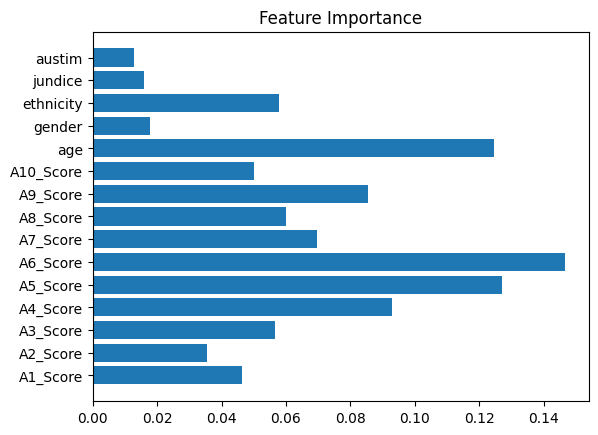

In [68]:
import matplotlib.pyplot as plt

rf = models["Random Forest"]

importances = rf.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()


In [69]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd


In [70]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),

    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=200,
        random_state=42
    ),

    "Balanced RF": BalancedRandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Easy Ensemble": EasyEnsembleClassifier(
        n_estimators=10,
        random_state=42
    )
}


In [71]:
X_full = np.vstack([X_train, X_test])
y_full = np.hstack([y_train, y_test])

In [72]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    print(f"\nRunning CV for {name}...")

    scores = cross_val_score(model, X_full, y_full, cv=skf, scoring="accuracy")

    cv_results[name] = scores.mean()

    print("Scores:", scores)
    print("Mean CV Accuracy:", scores.mean())



Running CV for Random Forest...
Scores: [0.96984925 0.9798995  0.96984925 0.98241206 0.97236181]
Mean CV Accuracy: 0.9748743718592966

Running CV for Extra Trees...
Scores: [0.95728643 0.97236181 0.96231156 0.96733668 0.96733668]
Mean CV Accuracy: 0.9653266331658292

Running CV for Bagging...
Scores: [0.96733668 0.98241206 0.95226131 0.96482412 0.95477387]
Mean CV Accuracy: 0.964321608040201

Running CV for Balanced RF...
Scores: [0.96482412 0.97738693 0.96984925 0.9798995  0.97738693]
Mean CV Accuracy: 0.9738693467336683

Running CV for Easy Ensemble...
Scores: [1.         1.         1.         1.         0.99748744]
Mean CV Accuracy: 0.9994974874371859


In [73]:
cv_df = pd.DataFrame({
    "Model": cv_results.keys(),
    "CV Accuracy": cv_results.values()
}).sort_values("CV Accuracy", ascending=False)

cv_df


,Model,CV Accuracy
4,Easy Ensemble,0.999497
0,Random Forest,0.974874
3,Balanced RF,0.973869
1,Extra Trees,0.965327
2,Bagging,0.964322
